# Decision Tree Classifier

The code below demonstrates how the Decision Tree classifier is trained and tuned using the cost-complexity pruning approach (https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html) to prevent overfitting. The tuned model is then tested, followed by a discussion of the test results

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree, metrics

In [27]:
train = pd.read_csv('train_processed.csv')
validation = pd.read_csv('validation_processed.csv')
test = pd.read_csv('test_processed.csv')
train.head(2)

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,...,verif__Not Verified,verif__Source Verified,verif__Verified,purpose__consumer_needs,purpose__credit_card,purpose__debt_consolidation,purpose__home_improvement,purpose__other,list__f,list__w
0,0,25000.0,19.20,11.938200,6.39,9.0,0,10.150348,49.6,21.0,...,0,0,1,0,0,1,0,0,1,0
1,1,5000.0,13.67,10.686567,6.23,14.0,1,8.822470,45.8,38.0,...,1,0,0,1,0,0,0,0,0,1


In [28]:
# Features and Label
# for train 
y_train = train['loan_status']
X_train = train.iloc[:, 1:]

# for validation
y_val = validation['loan_status']
X_val = validation.iloc[:, 1:]

# for test
y_test = test['loan_status']
X_test = test.iloc[:, 1:]

In [29]:
# Confirm the imbalance in the target variable frequencies once again
y_train.value_counts(normalize=True)

loan_status
0    0.802601
1    0.197399
Name: proportion, dtype: float64

## Model Training

Initially I train two classifiers on different criterions and compare the complexity

In [30]:
estimator_g =  tree.DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=42)
estimator_g.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [31]:
print('Tree depth:', estimator_g.get_depth())
print('Number of leaves: ', estimator_g.get_n_leaves())
print('Number of nodes: ', estimator_g.tree_.node_count)

Tree depth: 52
Number of leaves:  44683
Number of nodes:  89365


In [32]:
estimator_e =  tree.DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=42)
estimator_e.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [33]:
print('Tree depth:', estimator_e.get_depth())
print('Number of leaves: ', estimator_e.get_n_leaves())
print('Number of nodes: ', estimator_e.tree_.node_count)

Tree depth: 49
Number of leaves:  41331
Number of nodes:  82661


The estimator using the 'entropy' criterion produces a slightly shallower tree, which is generally preferable. Therefore, this criterion will be used for further pruning

## Model Tuning and Evaluation

In [34]:
pruning_path = pd.DataFrame(estimator_e.cost_complexity_pruning_path(X_train, y_train))
pruning_path.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21563 entries, 0 to 21562
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ccp_alphas  21563 non-null  float64
 1   impurities  21563 non-null  float64
dtypes: float64(2)
memory usage: 337.1 KB


There are ~21.5k candidate values for the ccp_alpha hyperparameter. I can sample these values at intervals of 500 to identify the optimal pruning parameter

In [35]:
ccp_alphas_sample = pruning_path['ccp_alphas'][::500]
ccp_alphas_sample.info()

<class 'pandas.core.series.Series'>
RangeIndex: 44 entries, 0 to 21500
Series name: ccp_alphas
Non-Null Count  Dtype  
--------------  -----  
44 non-null     float64
dtypes: float64(1)
memory usage: 484.0 bytes


In [36]:
results = []

for alpha in ccp_alphas_sample:
    estimator = tree.DecisionTreeClassifier(ccp_alpha=alpha, criterion='entropy', class_weight='balanced', random_state=42)

    estimator.fit(X_train, y_train)

    y_pred = estimator.predict(X_val)
    y_score = estimator.predict(X_val)

    results.append({
        'ccp_alpha': alpha,
        'depth' : estimator.get_depth(),
        'leaves': estimator.get_n_leaves(),
        'F1': metrics.f1_score(y_val, y_pred),
        'Recall': metrics.recall_score(y_val, y_pred),
        'Precision': metrics.precision_score(y_val, y_pred),
        'Roc_Auc': metrics.roc_auc_score(y_val, y_score)
    })

In [37]:
pd.DataFrame(results).sort_values('F1', ascending=False).head(5)

,ccp_alpha,depth,leaves,F1,Recall,Precision,Roc_Auc
43,0.000117,8,66,0.413642,0.643707,0.304729,0.641248
42,0.000047,29,1395,0.407745,0.674133,0.292257,0.636316
41,0.000040,34,3072,0.395451,0.672052,0.280149,0.623673
40,0.000037,39,4656,0.388813,0.662735,0.275106,0.616626
39,0.000034,42,6205,0.380741,0.636769,0.271555,0.608335


Our champion is an estimator with the ccp_alpha value **0.000117**

In [38]:
estimator_tuned = tree.DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=42, ccp_alpha=0.000117)
estimator_tuned.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [46]:
y_train_pred = estimator_tuned.predict(X_train)
y_val_pred = estimator_tuned.predict(X_val)

print('Train Confusion Matrix: \n', metrics.confusion_matrix(y_train, y_train_pred), '\n')
print('Train Recall:', round(metrics.recall_score(y_train, y_train_pred), 3))
print('Train Precision:', round(metrics.precision_score(y_train, y_train_pred), 3), '\n')
print('Validation Confusion Matrix: \n', metrics.confusion_matrix(y_val, y_val_pred), '\n')
print('Validation Recall:', round(metrics.recall_score(y_val, y_val_pred), 3))
print('Validation Precision:', round(metrics.precision_score(y_val, y_val_pred), 3), '\n')

print('F1 score train:', round(metrics.f1_score(y_train, y_train_pred), 3))
print('F1 score validation:', round(metrics.f1_score(y_val, y_val_pred), 3))

Train Confusion Matrix: 
 [[122557  68897]
 [ 16004  31084]] 

Train Recall: 0.66
Train Precision: 0.311 

Validation Confusion Matrix: 
 [[26207 14819]
 [ 3595  6495]] 

Validation Recall: 0.644
Validation Precision: 0.305 

F1 score train: 0.423
F1 score validation: 0.414


The model seems to generalise quite well but a bit worse than Logistic Regression

In [40]:
y_val_score = estimator_tuned.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.01, 1, 0.01)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    pred = (y_val_score >= t).astype(int)

    f1 = metrics.f1_score(y_val, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print('The best Classification Threshold:', best_threshold)
print('The best F1 score:', round(best_f1, 3))

The best Classification Threshold: 0.5
The best F1 score: 0.414


Default decision threshold is still optimal, which is close to the respective results of the Logistic Regression. Now, let's assess the most important predictors using the Mean Decrease in Impurity (MDI), which measures the total information gain contributed by each feature

In [41]:
feature_importance = pd.DataFrame({'Feature': X_val.columns, 'Importance': estimator_tuned.feature_importances_})

feature_importance.sort_values('Importance', ascending=False).head(10)

,Feature,Importance
1,int_rate,0.726664
12,term__ 36 months,0.099336
3,dti,0.081231
2,annual_inc,0.030578
18,home__MORTGAGE,0.021606
0,loan_amnt,0.014413
9,mort_acc,0.008833
21,home__RENT,0.006567
13,term__ 60 months,0.004958
7,revol_util,0.002884


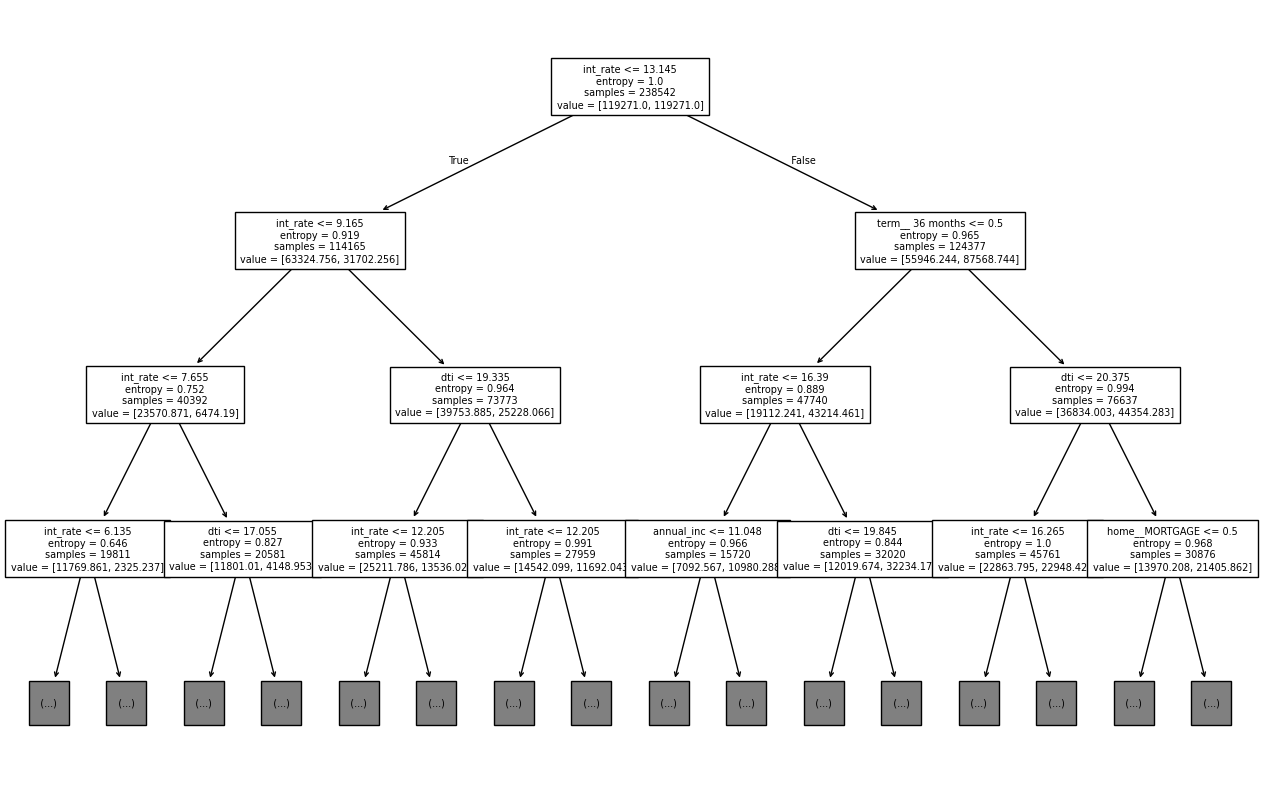

In [42]:
#visualisation of the pruned tree
fig, ax = plt.subplots(figsize=(16, 10))
txt = tree.plot_tree(estimator_tuned, fontsize=7, ax=ax, feature_names=X_val.columns, max_depth = 3)

## Model Testing

In [43]:
y_test_pred = estimator_tuned.predict(X_test)
y_test_score = estimator_tuned.predict_proba(X_test)[:,1]

In [44]:
print('Test Confusion Matrix: \n', metrics.confusion_matrix(y_test, y_test_pred), '\n')
print('Test Recall:', round(metrics.recall_score(y_test, y_test_pred), 3))
print('Test Precision:', round(metrics.precision_score(y_test, y_test_pred), 3), '\n')
print('F1 score test:', round(metrics.f1_score(y_test, y_test_pred), 3))

Test Confusion Matrix: 
 [[25996 15031]
 [ 3501  6589]] 

Test Recall: 0.653
Test Precision: 0.305 

F1 score test: 0.416


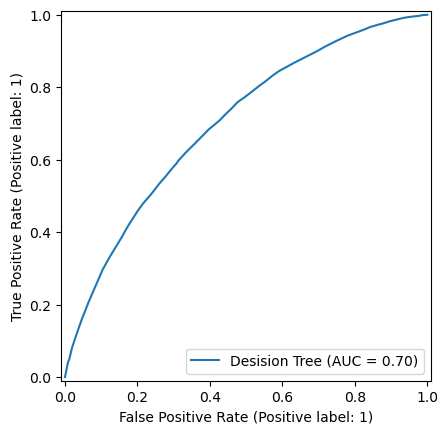

In [45]:
metrics.RocCurveDisplay.from_predictions(y_test, y_test_score, name='Desision Tree')
plt.show()

## Conclusion

The Decision Tree model achieved an **F1 score** of **0.416** with a **recall** of **65.3%**, which is comparable, but slightly worse than logistic regression model. which is comparable to, but slightly worse than, the Logistic Regression model. This suggests that neither the linear nor the non-linear relationships captured by the available features are strong enough to achieve substantially better predictive performance. The variable *int_rate* was by far the most influential predictor, significantly outperforming the remaining features in terms of predictive power. he next step is to evaluate ensemble methods, which may be able to capture more complex patterns in the data and improve overall model performance

**Top Predictors:**

| Feature | Importance | 
|:-----------|:------------:|
| int_rate   |  0.726664   | 
| term__ 36 months        |  0.099336 | 
| dti|0.081231|
| annual_inc	 |0.030578|
| home__MORTGAGE	 |0.021606|

**Summary of the Test Metrics:**

| Metrics | Model Performance | 
|:-----------|:------------:|
| F1 Score   |  0.416   | 
| Precision        |  0.305 | 
| Recall|0.653|
| AUC |0.700|
